# 03 — Routing Efficiency

Notebooks 01 and 02 mapped the network's shape and its important nodes. This one asks the operational question: **when you actually send a payment from A to B, what route does it take and what does it cost?**

Lightning uses **source routing**. The *sender* computes the entire path in advance and wraps the payment in onion-style layers, so each forwarding node learns only the previous and next hop — never the full route or the final destination. Every middle node charges a **fee** for forwarding and demands a **time-lock** (CLTV) as collateral against the payment getting stuck. Choosing a route means trading off fees, time-lock risk, and the number of hops. This notebook walks through finding the cheapest route, listing alternatives, and characterising the fee landscape across the whole network.

In [1]:
%matplotlib inline
import os
import json
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

from lngraph.ingest import ingest
from lngraph.graph import simplify, largest_connected_component
import lngraph.routing as rte

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "figure.facecolor": "white"})

_here = Path().resolve()
PROJECT_ROOT = _here
while not (PROJECT_ROOT / "lngraph").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

_override = os.environ.get("LNGRAPH_SNAPSHOT_DIR")
SNAPSHOT_DIR = Path(_override) if _override else PROJECT_ROOT / "data" / "snapshots"
SNAPSHOT_PATH = SNAPSHOT_DIR / "describegraph.json"

try:
    _disp = SNAPSHOT_PATH.relative_to(PROJECT_ROOT)
except ValueError:
    _disp = SNAPSHOT_PATH
print(f"Snapshot path : {_disp}")

Snapshot path : data/snapshots/describegraph.json


In [2]:
if not SNAPSHOT_PATH.exists():
    raise FileNotFoundError(
        f"No snapshot at {SNAPSHOT_PATH} — run `make crawl` to build one.\n"
        "This notebook requires real Lightning Network data and has no synthetic fallback."
    )

dg = json.loads(SNAPSHOT_PATH.read_text())
data_source = "snapshot"
print(f"Loaded snapshot: {len(dg['nodes'])} nodes, {len(dg['edges'])} channels")

G = ingest(dg)
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
print(f"Data source   : {data_source}")
print(f"MultiDiGraph  : {n_nodes:,} nodes  {n_edges:,} channels")

Loaded snapshot: 9990 nodes, 44501 channels


Data source   : snapshot
MultiDiGraph  : 9,990 nodes  89,002 channels


## 1 · Finding a route, with the real cost function

A forwarding node's charge has two parts: a flat **base fee** (in millisatoshi, charged per payment regardless of size) and a **proportional fee** (in parts-per-million of the amount). On top of the money cost, each hop adds a **CLTV delta** — the number of Bitcoin blocks your funds could be frozen if that hop fails mid-payment. Blocks arrive ~10 minutes apart, so **blocks ÷ 6 ≈ hours** (144 blocks ≈ 1 day). That time-lock is a genuine risk, so the routing cost folds it in:

```
cost = base_fee_msat + amount_msat × fee_rate_ppm / 1_000_000 + cltv_risk_weight × cltv_delta
```

We run **Dijkstra's shortest-path algorithm** on this cost to find the cheapest route, collapsing parallel channels to their cheapest non-disabled option and dropping disabled ones. The worked example sends **100,000 msat (100 sat) from ACINQ to bfx-lnd0**: a 2-hop route via Blockstream PeerSwap, total fee **119.9 msat (0.12 sat)** and **178 blocks (~30 hours)** of cumulative time-lock. Note how cheap that is — routing a 100-sat payment costs a tenth of a satoshi. Lightning fees are tiny; the scarce resources are *liquidity* and *reliability*, which the next notebook tackles.

In [3]:
all_nodes = list(G.nodes())
alias_map = {n: G.nodes[n].get("alias", n[:10]) for n in all_nodes}

AMOUNT_MSAT = 100_000  # 100 sat payment

if n_nodes >= 2:
    src = all_nodes[0]
    dst = all_nodes[1] if n_nodes == 2 else all_nodes[min(2, n_nodes - 1)]

    route = rte.find_route(G, src, dst, amount_msat=AMOUNT_MSAT)
    if route:
        print(f"Source : {alias_map.get(src, src[:12])}")
        print(f"Target : {alias_map.get(dst, dst[:12])}")
        print(f"Amount : {AMOUNT_MSAT:,} msat")
        print()
        print(f"Route  : {' → '.join(alias_map.get(p, p[:8]) for p in route['path'])}")
        print(f"Hops   : {route['hops']}")
        print(f"Total fee  : {route['total_fee_msat']:.1f} msat")
        print(f"Total CLTV : {route['total_cltv']} blocks (~{route['total_cltv'] / 6:.1f} h, at ~10 min/block)")
        print()
        df_hops = pd.DataFrame(route["per_hop"])
        df_hops["from"] = df_hops["from"].map(lambda p: alias_map.get(p, p[:8]))
        df_hops["to"] = df_hops["to"].map(lambda p: alias_map.get(p, p[:8]))
        print(df_hops.to_string(index=False))
    else:
        print("No route found between selected nodes.")
else:
    print("Need at least 2 nodes for routing.")

Source : ACINQ
Target : bfx-lnd0
Amount : 100,000 msat

Route  : ACINQ → Blockstream PeerSwap → bfx-lnd0
Hops   : 2
Total fee  : 119.9 msat
Total CLTV : 178 blocks (~29.7 h, at ~10 min/block)

                from                   to         channel_id  fee_msat  cltv_delta
               ACINQ Blockstream PeerSwap 948350769333403648      49.9         144
Blockstream PeerSwap             bfx-lnd0 758931304036302849      70.0          34


## 2 · Alternative routes (k-shortest paths)

The cheapest route is rarely the only option. **Yen's algorithm** enumerates the k best *simple* (loop-free) paths in cost order, which matters for two reasons: the first-choice route may not have enough liquidity at payment time, and comparing alternatives reveals the trade-offs on offer.

The alternatives are revealing. The top route is **2 hops / 119.9 msat**, but rank 3 is **5 hops / 65.1 msat — cheaper in raw fee despite more than twice the hops.** Why doesn't Dijkstra pick it first? Because the cost function also charges for time-lock, and the 5-hop route piles up **270 blocks (~45 hours)** of CLTV against the 2-hop route's 178 (~30 hours). The short route wins on *combined* cost even though it loses on fee alone. The lesson: more hops can dodge an expensive hub's base fee and lower your fee, but they raise your time-lock exposure — there's no free lunch, only a trade you choose.

In [4]:
K = 5

if n_nodes >= 2:
    kroutes = rte.find_k_routes(G, src, dst, k=K, amount_msat=AMOUNT_MSAT)
    print(f"k-shortest routes ({len(kroutes)} found, k={K})")
    print()
    rows = []
    for i, r in enumerate(kroutes):
        rows.append({
            "rank": i + 1,
            "hops": r["hops"],
            "total_fee_msat": r["total_fee_msat"],
            "total_cltv": r["total_cltv"],
            "path": " → ".join(alias_map.get(p, p[:8]) for p in r["path"]),
        })
    if rows:
        print(pd.DataFrame(rows).to_string(index=False))
else:
    print("Need at least 2 nodes.")

k-shortest routes (5 found, k=5)

 rank  hops  total_fee_msat  total_cltv                                                                                                path
    1     2           119.9         178                                                             ACINQ → Blockstream PeerSwap → bfx-lnd0
    2     4            83.1         246                                  ACINQ → Blockstream PeerSwap → absolute.money → aybabtu → bfx-lnd0
    3     5            65.1         270 ACINQ → Blockstream PeerSwap → 1sats.com⚡️lsp.flashsats.xyz → Boltz|CLN → LQWD-Australia → bfx-lnd0
    4     4            84.7         252                                     ACINQ → Blockstream PeerSwap → ORANGEIRON → MUTATRUM → bfx-lnd0
    5     4            81.0         258             ACINQ → Blockstream PeerSwap → 1sats.com⚡️lsp.flashsats.xyz → LQWD-Australia → bfx-lnd0


## 3 · Fee-vs-Hops Trade-off

`fee_vs_hops()` returns routes sorted by total fee (CLTV excluded) so `routes[0]`
is always the minimum-fee route, even when a longer path is cheaper than a shorter
one with higher base fees. The table below shows this for one example pair.

A single hub-to-hub pair is uninformative for the *network* question — between two
core hubs every route costs about the same. To see whether the network actually
prices route length, Fig3.1 samples many random routable pairs and plots the
minimum-fee route's hops vs fee, with the median fee per hop-count as a trend line.

Example pair ACINQ → bfx-lnd0: 10 routes
 hops  total_fee_msat  total_cltv
    4            53.9         338
    6            54.0         562
    6            54.2         562
    4            54.4         358
    5            54.8         446
    5            54.9         482
    5            54.9         482
    5            54.9         502
    5            55.1         396
    5            55.1         436



Network-wide sample: 152 routable pairs of 700 attempts (amount=100,000 msat)


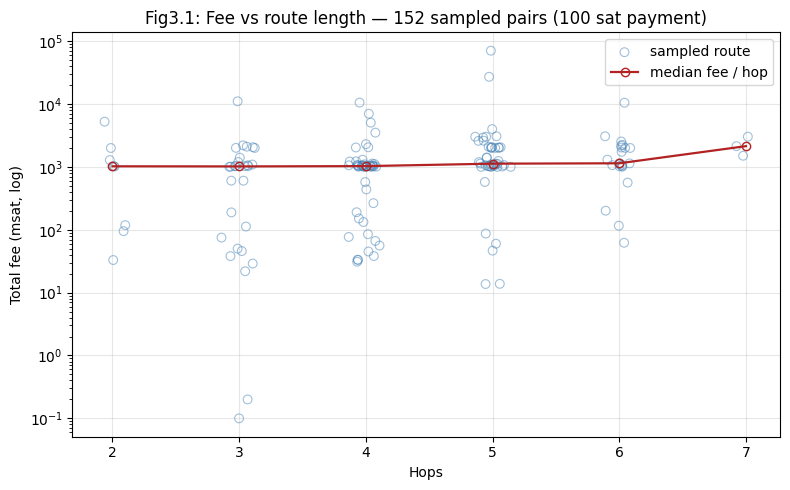

In [5]:
if n_nodes >= 2:
    fvh = rte.fee_vs_hops(G, src, dst, k=10, amount_msat=AMOUNT_MSAT)
    print(f"Example pair {alias_map.get(src, src[:8])} → {alias_map.get(dst, dst[:8])}: "
          f"{len(fvh)} routes")
    rows = [
        {"hops": r["hops"], "total_fee_msat": round(r["total_fee_msat"], 1), "total_cltv": r["total_cltv"]}
        for r in fvh
    ]
    if rows:
        print(pd.DataFrame(rows).to_string(index=False))

# Network-wide fee-vs-hops: sample random routable pairs so the relationship
# between route length and fee is visible across the whole graph.
rng = np.random.default_rng(42)
node_list = list(G.nodes())
N_ATTEMPTS = 700
TARGET = 200
samp_hops, samp_fee = [], []
attempts = 0
for attempts in range(N_ATTEMPTS):
    a, b = rng.integers(0, len(node_list), size=2)
    if a == b:
        continue
    r = rte.find_route(G, node_list[a], node_list[b], amount_msat=AMOUNT_MSAT)
    if r:
        samp_hops.append(r["hops"])
        samp_fee.append(r["total_fee_msat"])
    if len(samp_hops) >= TARGET:
        break

print(f"\nNetwork-wide sample: {len(samp_hops)} routable pairs of {attempts + 1} attempts "
      f"(amount={AMOUNT_MSAT:,} msat)")

if samp_hops:
    samp_hops = np.array(samp_hops)
    samp_fee = np.array(samp_fee, dtype=float)
    uniq = sorted(set(samp_hops.tolist()))
    med_fee = [float(np.median(samp_fee[samp_hops == h])) for h in uniq]

    fig, ax = plt.subplots(figsize=(8, 5))
    jitter = rng.normal(0, 0.06, size=len(samp_hops))
    ax.scatter(samp_hops + jitter, np.clip(samp_fee, 0.1, None),
               facecolors="none", edgecolors="steelblue", s=40, alpha=0.5,
               linewidths=0.8, zorder=3, label="sampled route")
    ax.plot(uniq, np.clip(med_fee, 0.1, None), "o-", color="firebrick",
            markerfacecolor="none", lw=1.6, zorder=4, label="median fee / hop")
    ax.set_yscale("log")
    ax.set_xlabel("Hops")
    ax.set_ylabel("Total fee (msat, log)")
    ax.set_title(f"Fig3.1: Fee vs route length — {len(samp_hops)} sampled pairs "
                 f"({AMOUNT_MSAT // 1000:,} sat payment)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No routable pairs sampled.")

## 4 · The fee landscape across the network

Routing algorithms navigate whatever fees operators have set, so it's worth seeing the whole distribution. We pull **base fee**, **fee rate (ppm)** and **CLTV delta** from every enriched channel direction (70,969 of them; unenriched channels with no policy are excluded).

The **medians are the story: 100 msat base fee, 100 ppm fee rate, 80-block CLTV (~13 h)** — modest and sane. But watch the *means*: base-fee mean ≈ 5.8 *million* msat, fee-rate mean ≈ 5.3 million ppm. Those aren't typos — a tail of operators set deliberately **prohibitive** fees (e.g. a 1,000,000-ppm rate = 100% of the amount) to effectively switch a channel direction off without closing it. Routing simply never picks those, but they wreck the average. This is the textbook reason to **report medians, not means, for heavy-tailed data**. A ppm refresher: 100 ppm is 0.01%, so it costs 100 sat to move 1,000,000 sat. The histograms use a log y-axis because of that same long tail.

Enriched channel directions: 70,969
Base fee  : median=100, mean=5827928, p95=1000 msat
Fee rate  : median=100, mean=5342243, p95=3000 ppm
CLTV delta: median=80 blocks (~13.3 h, at ~10 min/block)


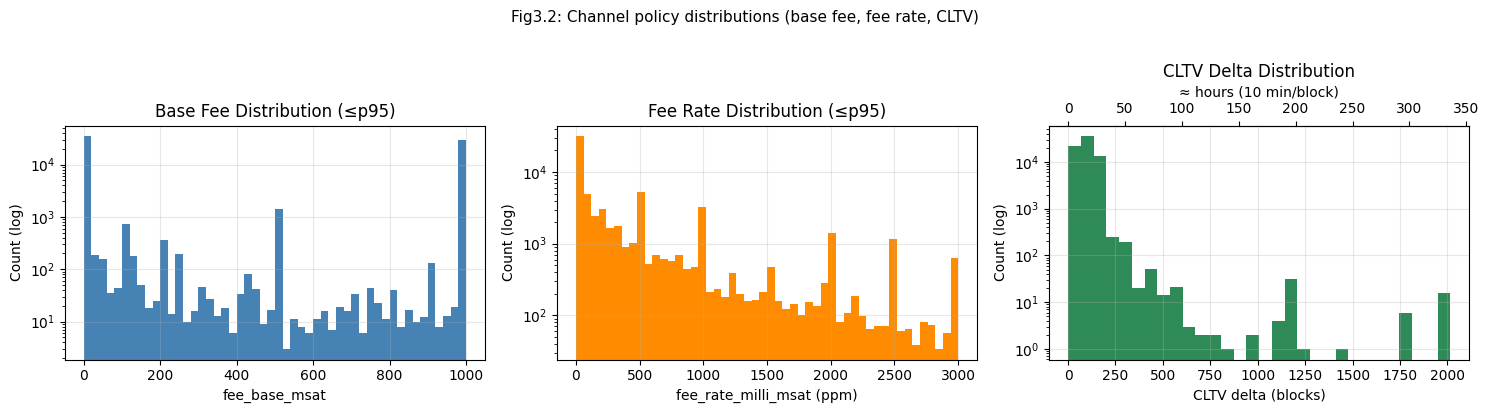

In [6]:
base_fees = []
fee_rates = []
cltv_deltas = []

for u, v, data in G.edges(data=True):
    pol = data.get("policy")
    if not pol:
        continue
    try:
        base_fees.append(int(pol.get("fee_base_msat", 0)))
        fee_rates.append(int(pol.get("fee_rate_milli_msat", 0)))
        cltv_deltas.append(int(pol.get("time_lock_delta", 0)))
    except (ValueError, TypeError):
        pass

print(f"Enriched channel directions: {len(base_fees):,}")

if base_fees:
    print(f"Base fee  : median={np.median(base_fees):.0f}, mean={np.mean(base_fees):.0f}, "
          f"p95={np.percentile(base_fees, 95):.0f} msat")
    print(f"Fee rate  : median={np.median(fee_rates):.0f}, mean={np.mean(fee_rates):.0f}, "
          f"p95={np.percentile(fee_rates, 95):.0f} ppm")
    print(f"CLTV delta: median={np.median(cltv_deltas):.0f} blocks (~{np.median(cltv_deltas) / 6:.1f} h, at ~10 min/block)")

    if len(base_fees) >= 10:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        cap95_base = np.percentile(base_fees, 95)
        cap95_rate = np.percentile(fee_rates, 95)
        filtered_base = [x for x in base_fees if x <= cap95_base]
        filtered_rate = [x for x in fee_rates if x <= cap95_rate]

        axes[0].hist(filtered_base, bins=50, color="steelblue", edgecolor="none")
        axes[0].set_xlabel("fee_base_msat")
        axes[0].set_title("Base Fee Distribution (≤p95)")

        axes[1].hist(filtered_rate, bins=50, color="darkorange", edgecolor="none")
        axes[1].set_xlabel("fee_rate_milli_msat (ppm)")
        axes[1].set_title("Fee Rate Distribution (≤p95)")

        axes[2].hist(cltv_deltas, bins=30, color="seagreen", edgecolor="none")
        axes[2].set_xlabel("CLTV delta (blocks)")
        axes[2].set_title("CLTV Delta Distribution")
        # blocks are ~10 min apart -> add a top axis in hours (blocks / 6)
        secax = axes[2].secondary_xaxis("top", functions=(lambda b: b / 6.0, lambda h: h * 6.0))
        secax.set_xlabel("≈ hours (10 min/block)")

        for ax in axes:
            ax.set_yscale("log")
            ax.set_ylabel("Count (log)")
            ax.grid(True, alpha=0.3)
        plt.suptitle("Fig3.2: Channel policy distributions (base fee, fee rate, CLTV)", y=1.02, fontsize=11)
        plt.tight_layout()
        plt.show()
else:
    print("No enriched channels found (run policy enrichment first).")

In [7]:
# Summary metrics (filled live from the loaded graph + enrichment)
_enriched = sum(1 for _, _, d in G.edges(data=True) if d.get("policy"))
_summary = pd.DataFrame([
    {"Metric": "Nodes", "Value": f"{G.number_of_nodes():,}"},
    {"Metric": "Channel directions (edges)", "Value": f"{G.number_of_edges():,}"},
    {"Metric": "Enriched (with policy)",
     "Value": f"{_enriched:,} ({100 * _enriched / G.number_of_edges():.1f}%)"},
])
print(_summary.to_string(index=False))

                    Metric          Value
                     Nodes          9,990
Channel directions (edges)         89,002
    Enriched (with policy) 70,969 (79.7%)


## Summary

Key takeaways:
- The cheapest-fee route and the Dijkstra-cost-optimal route can differ when
  CLTV risk is included in the cost function — `fee_vs_hops()` exposes this.
- k-shortest paths reveal alternative routes with different fee/CLTV profiles,
  giving a sender choices for redundancy or cost/risk balance.
- Across sampled pairs (Fig3.1) the median fee rises with hop count — longer
  routes cost more, but the spread is wide: a 5-hop route can undercut a 3-hop one.
- Base fees cluster near 0–1000 msat; fee rates cluster near 0–500 ppm for
  most channels, with long tails for premium routing nodes (Fig3.2).

The live metrics above replace the old static table.

Next: **04 — Liquidity & Partial Observability** (success probability model).